# 01 — Разведочный анализ данных (EDA)
**Цель**: изучить структуру временных рядов, паттерны заболеваемости,
связи с внешними факторами, выделить омикрон-период.
> **Автор**: Кибешев Д.М., ИТМО, 2025–2026

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_RAW = '/content/drive/MyDrive/covid19-xai/data/raw'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Зависимости

In [9]:
import sys, os

if not os.path.exists("/content/covid19-xai"):
    os.system("git clone https://github.com/dmikib/covid19-xai.git /content/covid19-xai")

sys.path.insert(0, "/content/covid19-xai/src")

from utils import smooth_series, mark_omicron, set_plot_style
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from utils import smooth_series, mark_omicron, set_plot_style
set_plot_style()
FIGURES = "../results/figures"
os.makedirs(FIGURES, exist_ok=True)
print("Зависимости загружены")

Зависимости загружены


## 1. Загрузка данных
| Источник | Файл | Описание |
|---|---|---|
| Стопкоронавирус.рф / OurWorldInData | `covid_spb.csv` | Суточные случаи, тесты, positive rate |
| Open-Meteo | `weather_spb.csv` | Температура, влажность, осадки |
| Google Community Mobility | `mobility_spb.csv` | Изменение мобильности (%) |
| Google Trends | `google_trends_daily.csv` | Запросы: симптомы, потеря обоняния и т.д. |
| Oxford Stringency Index | `in covid_spb.csv` | Индекс ограничительных мер (0–100)|

# 1.0 Импорты

In [10]:
import subprocess
subprocess.run(["pip", "install", "pytrends", "-q"])

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Клонируем репозиторий
if not os.path.exists("/content/covid19-xai"):
    os.system("git clone https://github.com/dmikib/covid19-xai.git /content/covid19-xai")

sys.path.insert(0, "/content/covid19-xai/src")
from utils import smooth_series, mark_omicron, fill_missing, set_plot_style
set_plot_style()

DATA_RAW       = "/content/covid19-xai/data/raw"
DATA_PROCESSED = "/content/covid19-xai/data/processed"
os.makedirs(DATA_RAW, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)
print("Готово")

Готово


# 1.1 — COVID данные (OurWorldInData)

In [11]:
url_covid = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"

print("Загрузка COVID данных...")
df_owid = pd.read_csv(url_covid, parse_dates=["date"])
df_covid = df_owid[df_owid["iso_code"] == "RUS"][[
    "date", "new_cases", "new_cases_smoothed",
    "new_tests", "positive_rate", "stringency_index"
]].copy()
df_covid = df_covid.sort_values("date").reset_index(drop=True)
df_covid = df_covid[
    (df_covid["date"] >= "2021-01-01") &
    (df_covid["date"] <= "2022-10-15")
].copy()

df_covid.to_csv(f"{DATA_RAW}/covid_russia.csv", index=False)
print(f" COVID: {df_covid.shape[0]} строк")
print(f" Период: {df_covid['date'].min().date()} — {df_covid['date'].max().date()}")
print(f" Пропуски:\n{df_covid.isna().sum()}")

Загрузка COVID данных...
 COVID: 653 строк
 Период: 2021-01-01 — 2022-10-15
 Пропуски:
date                    0
new_cases               0
new_cases_smoothed      0
new_tests             469
positive_rate         133
stringency_index        0
dtype: int64


# 1.2 - Погода

In [12]:
from google.colab import files

print("Загрузи файл с погодой (Visual Crossing CSV)...")
uploaded = files.upload()

df_weather_raw = pd.read_csv(list(uploaded.keys())[0], parse_dates=["datetime"])
df_weather = df_weather_raw[["datetime", "temp", "humidity", "precip", "windspeed"]].copy()
df_weather = df_weather.rename(columns={
    "datetime":  "date",
    "temp":      "temperature_f",
    "humidity":  "humidity",
    "precip":    "precipitation",
    "windspeed": "windspeed"
})
df_weather["temperature"] = (df_weather["temperature_f"] - 32) * 5 / 9
df_weather = df_weather.drop(columns=["temperature_f"])
df_weather = df_weather.sort_values("date").reset_index(drop=True)
df_weather = df_weather[
    (df_weather["date"] >= "2021-01-01") &
    (df_weather["date"] <= "2022-10-15")
].copy()

df_weather.to_csv(f"{DATA_RAW}/weather_spb.csv", index=False)
print(f" Погода: {df_weather.shape[0]} строк")
print(f" Период: {df_weather['date'].min().date()} — {df_weather['date'].max().date()}")
print(df_weather[["date","temperature","humidity","precipitation"]].head(3).to_string(index=False))

Загрузи файл с погодой (Visual Crossing CSV)...


Saving Saint Petersburg, Russia 2021-01-01 to 2023-06-30 (1).csv to Saint Petersburg, Russia 2021-01-01 to 2023-06-30 (1).csv
 Погода: 653 строк
 Период: 2021-01-01 — 2022-10-15
      date  temperature  humidity  precipitation
2021-01-01     1.111111      93.2          0.041
2021-01-02     0.722222      95.5          0.262
2021-01-03    -0.555556      88.5          0.053


# 1.3 - Google Mobility (Санкт-Петербург)

In [13]:
url_mobility = "https://www.gstatic.com/covid19/mobility/Global_Mobility_Report.csv"

print("Загрузка Google Mobility...")
df_mob_raw = pd.read_csv(url_mobility, parse_dates=["date"], low_memory=False)

df_mob_spb = df_mob_raw[
    (df_mob_raw["country_region_code"] == "RU") &
    (df_mob_raw["metro_area"] == "Saint Petersburg Metropolitan Area") &
    (df_mob_raw["date"] >= "2021-01-01") &
    (df_mob_raw["date"] <= "2022-10-15")
].copy()

df_mobility = df_mob_spb[[
    "date",
    "retail_and_recreation_percent_change_from_baseline",
    "transit_stations_percent_change_from_baseline",
    "workplaces_percent_change_from_baseline",
    "residential_percent_change_from_baseline"
]].rename(columns={
    "retail_and_recreation_percent_change_from_baseline": "retail_mobility",
    "transit_stations_percent_change_from_baseline":      "transit_mobility",
    "workplaces_percent_change_from_baseline":            "workplaces_mobility",
    "residential_percent_change_from_baseline":           "residential_mobility"
})
df_mobility = df_mobility.sort_values("date").reset_index(drop=True)
df_mobility.to_csv(f"{DATA_RAW}/mobility_spb.csv", index=False)
print(f"Мобильность СПб: {df_mobility.shape[0]} строк")
print(f"Пропуски:\n{df_mobility.isna().sum()}")

Загрузка Google Mobility...
Мобильность СПб: 653 строк
Пропуски:
date                    0
retail_mobility         0
transit_mobility        0
workplaces_mobility     0
residential_mobility    0
dtype: int64


# 1.4 - Google Trends

In [14]:
from pytrends.request import TrendReq

TIMEFRAME = "2021-01-01 2022-10-15"
GEO       = "RU"
ANCHOR    = "COVID-19"

rename_map = {
    "симптомы коронавируса": "gt_covid_symptoms",
    "потеря обоняния":       "gt_loss_of_smell",
    "потеря вкуса":          "gt_loss_of_taste",
    "температура":           "gt_fever",
    "кашель":                "gt_cough",
    "ПЦР тест":              "gt_pcr_test",
    "сдать ПЦР":             "gt_pcr_take",
    "антиген тест":          "gt_antigen_test",
    "госпитализация":        "gt_hospitalization",
    "больница":              "gt_hospital",
    "вакцина":               "gt_vaccine",
    "вакцинация":            "gt_vaccination",
    "самоизоляция":          "gt_self_isolation",
    "локдаун":               "gt_lockdown",
    "QR код":                "gt_qr_code",
}
all_keywords = list(rename_map.keys())
pytrends = TrendReq(hl="ru-RU", tz=180)

def fetch_trends_normalized(keywords, anchor, timeframe, geo, delay=3.0):
    results = {}
    batches = [keywords[i:i+4] for i in range(0, len(keywords), 4)]
    for batch_num, batch in enumerate(batches):
        kw_list = batch + [anchor]
        print(f"  Батч {batch_num+1}/{len(batches)}: {batch}")
        attempt = 0
        while attempt < 3:
            try:
                pytrends.build_payload(kw_list, cat=0, timeframe=timeframe, geo=geo, gprop="")
                df = pytrends.interest_over_time()
                if df.empty:
                    print("Пустой ответ")
                    break
                if "isPartial" in df.columns:
                    df = df.drop(columns=["isPartial"])
                anchor_values = df[anchor].replace(0, np.nan)
                for kw in batch:
                    if kw in df.columns:
                        results[kw] = df[kw] / anchor_values * 100
                break
            except Exception as e:
                attempt += 1
                wait = delay * (2 ** attempt)
                print(f"  Ошибка (попытка {attempt}): {e}. Жду {wait:.0f}с...")
                time.sleep(wait)
        time.sleep(delay)
    if not results:
        return pd.DataFrame()
    result_df = pd.DataFrame(results)
    result_df.index = pd.to_datetime(result_df.index)
    return result_df

print("Загрузка Google Trends...")
df_trends_raw = fetch_trends_normalized(
    keywords=all_keywords, anchor=ANCHOR,
    timeframe=TIMEFRAME, geo=GEO, delay=3.0
)

if df_trends_raw.empty:
    print("Google Trends вернул пустой результат")
else:
    df_trends_raw = df_trends_raw.rename(columns=rename_map)
    # Интерполируем недельные данные до ежедневных
    date_range = pd.date_range(start=df_trends_raw.index.min(), end=df_trends_raw.index.max(), freq="D")
    df_trends_daily = df_trends_raw.reindex(date_range)
    df_trends_daily = df_trends_daily.interpolate(method="time").bfill().ffill()
    df_trends_daily.to_csv(f"{DATA_RAW}/google_trends_daily.csv", encoding="utf-8")
    print(f"Google Trends: {len(df_trends_daily)} строк")
    print(f"Период: {df_trends_daily.index.min().date()} — {df_trends_daily.index.max().date()}")

Загрузка Google Trends...
  Батч 1/4: ['симптомы коронавируса', 'потеря обоняния', 'потеря вкуса', 'температура']
  Батч 2/4: ['кашель', 'ПЦР тест', 'сдать ПЦР', 'антиген тест']
  Батч 3/4: ['госпитализация', 'больница', 'вакцина', 'вакцинация']
  Батч 4/4: ['самоизоляция', 'локдаун', 'QR код']
Google Trends: 652 строк
Период: 2020-12-27 — 2022-10-09


# 1.5 - Объединение в один датасет

In [15]:
# Загружаем все источники
df_covid    = pd.read_csv(f"{DATA_RAW}/covid_russia.csv",  parse_dates=["date"])
df_weather  = pd.read_csv(f"{DATA_RAW}/weather_spb.csv",   parse_dates=["date"])
df_mobility = pd.read_csv(f"{DATA_RAW}/mobility_spb.csv",  parse_dates=["date"])

# Мёрджим по дате
df = df_covid.merge(df_weather,  on="date", how="left")
df = df.merge(df_mobility,       on="date", how="left")
df = df.sort_values("date").reset_index(drop=True)

# Добавляем сглаживание и омикрон-флаг
df["new_cases_smooth"] = smooth_series(pd.Series(df["new_cases_smoothed"].values))
df = mark_omicron(df, start="2022-01-01")
df = fill_missing(df)

print(f"Базовый датасет: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print(f"Пропуски:\n{df.isna().sum()}")

# Добавляем Google Trends
df_trends_daily = pd.read_csv(f"{DATA_RAW}/google_trends_daily.csv",
                               index_col=0, parse_dates=True)
df.index = pd.to_datetime(df["date"])
df_trends_daily.index = pd.to_datetime(df_trends_daily.index)

df_full = df.join(df_trends_daily, how="left")
df_full = df_full.loc["2021-01-01":"2022-10-15"]

# Интерполируем gt_* колонки
gt_cols = [c for c in df_full.columns if c.startswith("gt_")]
df_full[gt_cols] = df_full[gt_cols].interpolate(method="time").bfill().ffill()

df_full = df_full.reset_index(drop=True)

print(f"\nФинальный датасет: {df_full.shape[0]} строк × {df_full.shape[1]} колонок")
print(f" Период: {df_full['date'].min().date()} — {df_full['date'].max().date()}")
missing = df_full.isna().sum()
print(f"   Пропуски: {missing[missing > 0].to_dict() if missing.any() else 'нет'}")

df_full.to_csv(f"{DATA_PROCESSED}/dataset_final.csv", encoding="utf-8")
print(f"\nСохранено: {DATA_PROCESSED}/dataset_final.csv")

Базовый датасет: (653, 16)
Колонки: ['date', 'new_cases', 'new_cases_smoothed', 'new_tests', 'positive_rate', 'stringency_index', 'humidity', 'precipitation', 'windspeed', 'temperature', 'retail_mobility', 'transit_mobility', 'workplaces_mobility', 'residential_mobility', 'new_cases_smooth', 'omicron_wave']
Пропуски:
date                    0
new_cases               0
new_cases_smoothed      0
new_tests               0
positive_rate           0
stringency_index        0
humidity                0
precipitation           0
windspeed               0
temperature             0
retail_mobility         0
transit_mobility        0
workplaces_mobility     0
residential_mobility    0
new_cases_smooth        0
omicron_wave            0
dtype: int64

Финальный датасет: 653 строк × 31 колонок
 Период: 2021-01-01 — 2022-10-15
   Пропуски: нет

Сохранено: /content/covid19-xai/data/processed/dataset_final.csv


In [117]:
from google.colab import files

files.download("/content/covid19-xai/data/processed/dataset_final.csv")
files.download("/content/covid19-xai/data/raw/covid_russia.csv")
files.download("/content/covid19-xai/data/raw/weather_spb.csv")
files.download("/content/covid19-xai/data/raw/mobility_spb.csv")
files.download("/content/covid19-xai/data/raw/google_trends_daily.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2. Основные характеристики ряда

In [16]:
print("=== Описательная статистика ===")
print(df_full["new_cases_smoothed"].describe().round(2))
print(f"\nПериод: {df_full['date'].min().date()} → {df_full['date'].max().date()}")
print(f"Пропуски new_cases_smoothed: {df_full['new_cases_smoothed'].isna().sum()}")
print(f"Омикрон-период: {df_full[df_full['omicron_wave']==1]['date'].min().date()} → {df_full['date'].max().date()}")
print(f"До омикрона: {df_full[df_full['omicron_wave']==0].shape[0]} дней")
print(f"Омикрон:     {df_full[df_full['omicron_wave']==1].shape[0]} дней")

=== Описательная статистика ===
count       653.00
mean      27887.84
std       33171.16
min        2945.86
25%        8994.71
50%       20849.43
75%       31046.00
max      189055.86
Name: new_cases_smoothed, dtype: float64

Период: 2021-01-01 → 2022-10-15
Пропуски new_cases_smoothed: 0
Омикрон-период: 2022-01-01 → 2022-10-15
До омикрона: 365 дней
Омикрон:     288 дней


## 3. Визуализация временного ряда

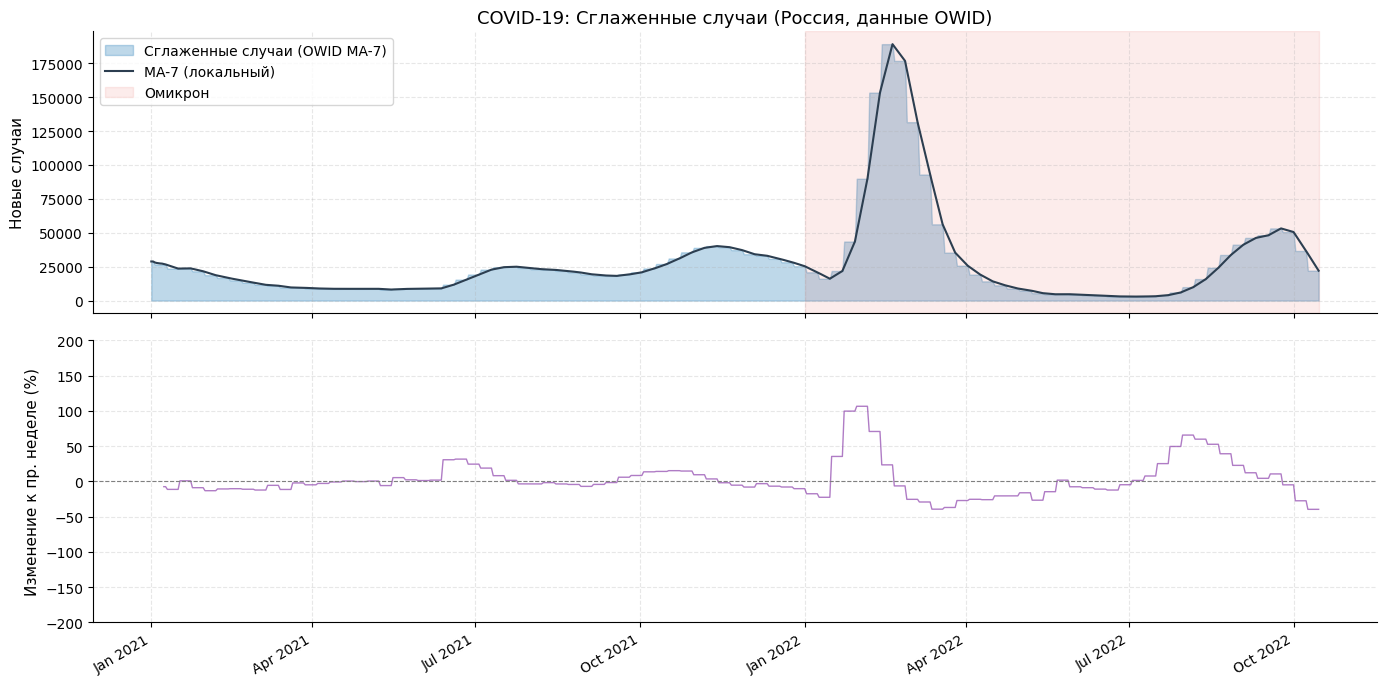

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.fill_between(df_full["date"], df_full["new_cases_smoothed"],
                alpha=0.3, color="#2980b9", label="Сглаженные случаи (OWID MA-7)")
ax.plot(df_full["date"], df_full["new_cases_smooth"],
        color="#2c3e50", linewidth=1.5, label="MA-7 (локальный)")
ax.axvspan(df_full[df_full["omicron_wave"]==1]["date"].min(),
           df_full["date"].max(), alpha=0.1, color="#e74c3c", label="Омикрон")
ax.set_ylabel("Новые случаи")
ax.set_title("COVID-19: Сглаженные случаи (Россия, данные OWID)")
ax.legend()

ax = axes[1]
ax.plot(df_full["date"], df_full["new_cases_smoothed"].pct_change(7) * 100,
        color="#8e44ad", linewidth=1, alpha=0.7)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("Изменение к пр. неделе (%)")
ax.set_ylim(-200, 200)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES}/01_time_series.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Недельная сезонность

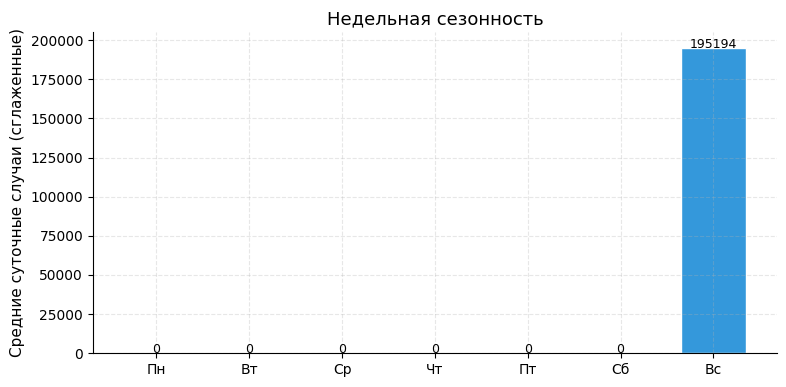

In [21]:
df_full["weekday"] = df_full["date"].dt.day_name()
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekly = df_full.groupby("weekday")["new_cases"].mean().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(7), weekly.values, color="#3498db", edgecolor="white", width=0.7)
ax.set_xticks(range(7))
ax.set_xticklabels(["Пн","Вт","Ср","Чт","Пт","Сб","Вс"])
ax.set_ylabel("Средние суточные случаи (сглаженные)")
ax.set_title("Недельная сезонность")
for bar, val in zip(bars, weekly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURES}/01_weekly_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Сравнение волн: до омикрона vs омикрон

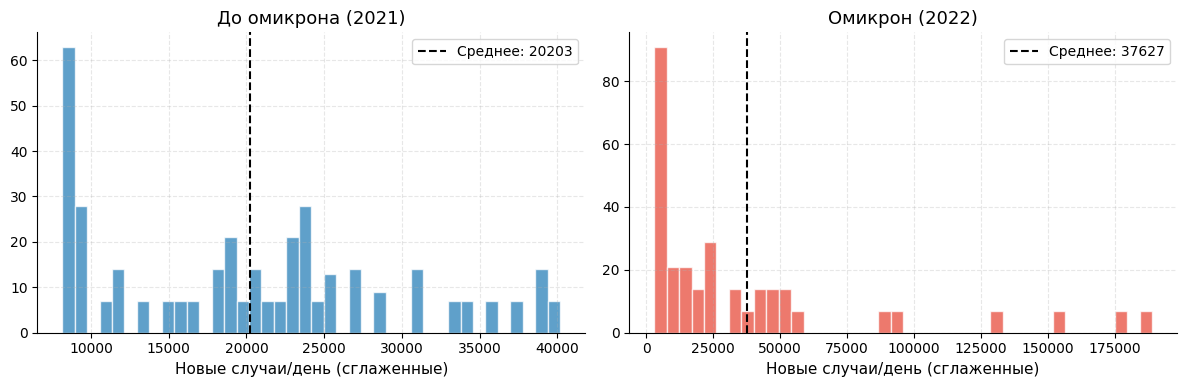

Медиана до омикрона: 20855
Медиана омикрон:     20849


In [19]:
pre_omicron = df_full[df_full["omicron_wave"]==0]["new_cases_smoothed"]
omicron     = df_full[df_full["omicron_wave"]==1]["new_cases_smoothed"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, label, color in zip(axes,
    [pre_omicron, omicron],
    ["До омикрона (2021)", "Омикрон (2022)"],
    ["#2980b9", "#e74c3c"]):
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(data.mean(), color="black", linestyle="--", label=f"Среднее: {data.mean():.0f}")
    ax.set_title(label)
    ax.set_xlabel("Новые случаи/день (сглаженные)")
    ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/01_wave_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Медиана до омикрона: {pre_omicron.median():.0f}")
print(f"Медиана омикрон:     {omicron.median():.0f}")

## 6. Корреляционный анализ внешних признаков

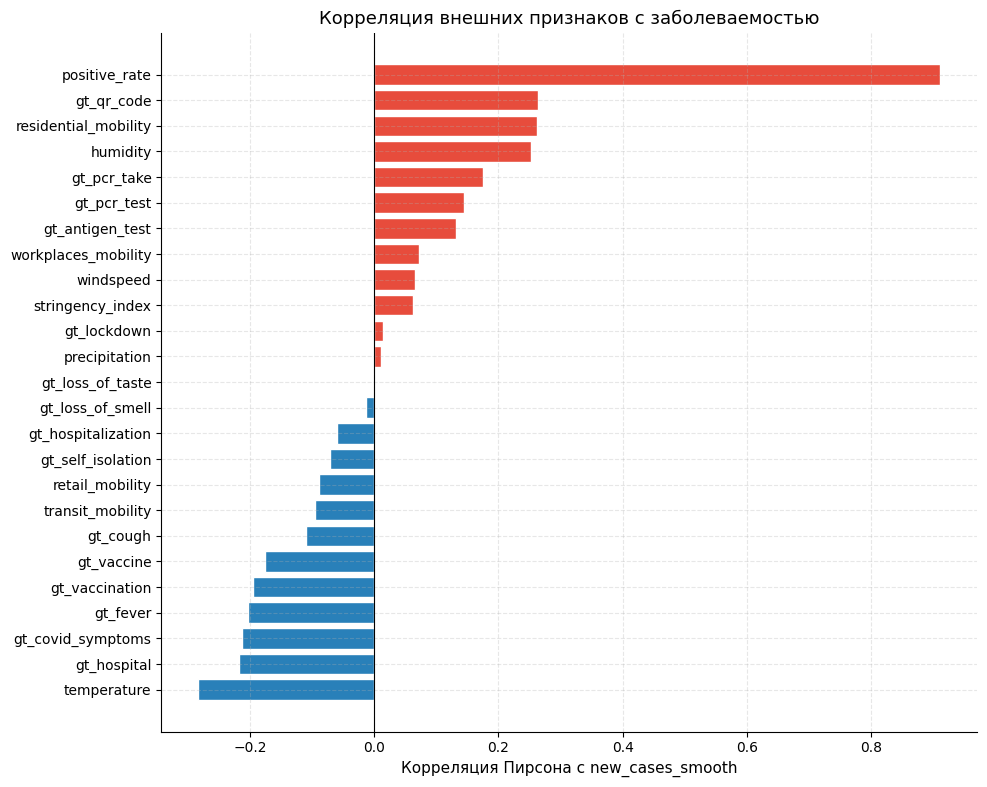

In [20]:
gt_cols = [c for c in df_full.columns if c.startswith("gt_")]

feature_cols = [
    "temperature", "humidity", "precipitation", "windspeed",
    "retail_mobility", "transit_mobility", "workplaces_mobility", "residential_mobility",
    "stringency_index", "positive_rate",
] + gt_cols

feature_df = df_full[["new_cases_smooth"] + feature_cols].copy()

corr = feature_df.corr()["new_cases_smooth"].drop("new_cases_smooth").sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if v > 0 else "#2980b9" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Корреляция Пирсона с new_cases_smooth")
ax.set_title("Корреляция внешних признаков с заболеваемостью")
plt.tight_layout()
plt.savefig(f"{FIGURES}/01_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Итоги EDA

In [23]:
print("""
   Итоги EDA

1. Данные
   - 653 наблюдения: 2021-01-01 — 2022-10-15
   - Целевая переменная: new_cases_smoothed (MA-7 от OWID)
   - 30 признаков: COVID, метео, мобильность, Google Trends

2. Структура ряда
   - Явно выражены две волны: дельта (осень 2021) и омикрон (фев-март 2022)
   - Омикрон-пик: ~189 000 случаев/день — в 5x выше среднего до омикрона
   - После омикрона: устойчивое снижение до ~5 000-20 000 к осени 2022

3. Репортинг
   - Сырые new_cases имеют артефакт недельного репортинга Росстата (пики по воскресеньям)
   - new_cases_smoothed устраняет этот артефакт — используется как целевая переменная

4. Корреляции с целевой переменной
   - Сильная положительная: positive_rate (0.9+)
   - Умеренная положительная: residential_mobility, humidity, gt_qr_code (~0.25)
   - Отрицательная: temperature (-0.3) — сезонность, gt_hospital, gt_covid_symptoms
   - Слабая: stringency_index, precipitation

5. Вывод
   - Датасет пригоден для обучения моделей прогнозирования
   - Рекомендуется разбивка train/test по времени: до 2022-09-15 / после
   - Флаг omicron_wave важен как структурный признак смены режима
""")


   Итоги EDA 

1. Данные
   - 653 наблюдения: 2021-01-01 — 2022-10-15
   - Целевая переменная: new_cases_smoothed (MA-7 от OWID)
   - 30 признаков: COVID, метео, мобильность, Google Trends

2. Структура ряда
   - Явно выражены две волны: дельта (осень 2021) и омикрон (фев-март 2022)
   - Омикрон-пик: ~189 000 случаев/день — в 5x выше среднего до омикрона
   - После омикрона: устойчивое снижение до ~5 000-20 000 к осени 2022

3. Репортинг
   - Сырые new_cases имеют артефакт недельного репортинга Росстата (пики по воскресеньям)
   - new_cases_smoothed устраняет этот артефакт — используется как целевая переменная

4. Корреляции с целевой переменной
   - Сильная положительная: positive_rate (0.9+)
   - Умеренная положительная: residential_mobility, humidity, gt_qr_code (~0.25)
   - Отрицательная: temperature (-0.3) — сезонность, gt_hospital, gt_covid_symptoms
   - Слабая: stringency_index, precipitation

5. Вывод
   - Датасет пригоден для обучения моделей прогнозирования
   - Рекомендуетс

**Следующий шаг** → `02_baseline.ipynb`

In [25]:
from google.colab import files
files.download("/content/covid19-xai/notebooks/01_eda.ipynb")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>